# Predicting Movie Success - Manual MLP

**Shawn Lokshin, Fedor Bentsa, Borys Kocherev**

This notebook is the manual version of our MLP. Everything is built from scratch with numpy and pandas only (no sklearn, no keras). The target is the same as the Bayesian R model: `success = 1` if `revenue > budget`, else `0`, so the two models are clearly comparable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json

np.random.seed(42)

## Load and clean the data

In [2]:
# load the csv
df = pd.read_csv("tmdb_5000_movies.csv")
print("original shape:", df.shape)

# same filters as the Bayesian R model so the two are comparable
# drop rows with missing or zero budget (those are clearly bad data)
df = df[
    (df["budget"] > 0) &
    (df["revenue"] >= 0) &
    df["runtime"].notna() & (df["runtime"] > 0) &
    df["popularity"].notna() & (df["popularity"] > 0) &
    df["genres"].notna() &
    df["release_date"].notna()
].copy()

# target: 1 if the movie made more than its budget back
df["success"] = (df["revenue"] > df["budget"]).astype(int)

df = df.reset_index(drop=True)
print("after cleaning:", df.shape)
print("class balance:")
print(df["success"].value_counts(normalize=True).round(3))

original shape: (4803, 20)
after cleaning: (3762, 21)
class balance:
success
1    0.648
0    0.352
Name: proportion, dtype: float64


## Parse genres
Genres are stored as a json-ish string, need to parse it to get the actual list of genre names.

In [3]:
def extract_names(x):
    # safely parse the genre string
    try:
        items = ast.literal_eval(x)
        return [item["name"] for item in items]
    except Exception:
        return []

df["genres_list"] = df["genres"].apply(extract_names)

# full set of genres in the dataset
all_genres = sorted(set(g for gs in df["genres_list"] for g in gs))
print("number of unique genres:", len(all_genres))
print(all_genres)

number of unique genres: 20
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


## Build the feature matrix

Features we use:
- log budget, runtime, log popularity, vote average, log vote count, release year + month
- one dummy per genre
- dummies for the top 10 languages (everything else becomes "other")


In [4]:
# make one dummy column per genre
for g in all_genres:
    df[f"genre_{g}"] = df["genres_list"].apply(lambda x, gg=g: 1 if gg in x else 0)

# release date features
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"]).copy()
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

# group languages: keep top 10, rest become "other"
top_langs = df["original_language"].value_counts().nlargest(10).index
df["lang_grouped"] = np.where(df["original_language"].isin(top_langs), df["original_language"], "other")

# dummy encode manually, drop the first so we don't get perfect collinearity
lang_vals = sorted(df["lang_grouped"].unique())
for lang in lang_vals[1:]:
    df[f"lang_{lang}"] = (df["lang_grouped"] == lang).astype(int)

# log transform the skewed variables (budget, popularity, vote count are all very right-skewed)
df["log_budget"] = np.log1p(df["budget"])
df["log_popularity"] = np.log1p(df["popularity"])
df["log_vote_count"] = np.log1p(df["vote_count"])

df = df.reset_index(drop=True)

numeric_cols = [
    "log_budget", "runtime", "log_popularity",
    "vote_average", "log_vote_count",
    "release_year", "release_month",
]
genre_cols = [f"genre_{g}" for g in all_genres]
lang_cols = [f"lang_{lang}" for lang in lang_vals[1:]]
feature_cols = numeric_cols + genre_cols + lang_cols

X = df[feature_cols].to_numpy(dtype=float)
y = df["success"].to_numpy(dtype=float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("number of features:", len(feature_cols))

X shape: (3762, 37)
y shape: (3762,)
number of features: 37


## Train / test split and standardization
Doing this manually since we can't use sklearn for the manual model.

In [5]:
# shuffle and split 80/20
n = len(X)
idx = np.arange(n)
np.random.shuffle(idx)
split = int(0.8 * n)

train_idx = idx[:split]
test_idx = idx[split:]

X_train_raw = X[train_idx]
X_test_raw = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# standardize using training stats only
# (fitting on the full data would leak info from the test set)
mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)
std[std == 0] = 1.0  # avoid divide by zero on any constant columns

X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

# take 20% of the training set as a validation set for early stopping
val_size = int(0.2 * len(X_train))
X_val = X_train[:val_size]
y_val = y_train[:val_size]
X_tr = X_train[val_size:]
y_tr = y_train[val_size:]

print("train:", X_tr.shape, " val:", X_val.shape, " test:", X_test.shape)

train: (2408, 37)  val: (601, 37)  test: (753, 37)


## Manual MLP

Basic feedforward network, two hidden layers. ReLU activations, sigmoid on the output.
Loss is binary cross-entropy, optimizer is mini-batch SGD.

Architecture:
- input → 64 (ReLU) → 32 (ReLU) → 1 (sigmoid)

We use He initialization since the hidden layers are ReLU.


In [6]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    # clip the input so exp doesn't overflow on very big values
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def bce(y_true, y_pred):
    # binary cross entropy loss
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


class ManualMLP:
    def __init__(self, input_dim, h1=64, h2=32, lr=0.01, seed=42):
        rng = np.random.default_rng(seed)
        # he init for the relu layers
        self.W1 = rng.standard_normal((input_dim, h1)) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(h1)
        self.W2 = rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)
        self.b2 = np.zeros(h2)
        # output layer uses a smaller init since it goes through sigmoid
        self.W3 = rng.standard_normal((h2, 1)) * np.sqrt(1.0 / h2)
        self.b3 = np.zeros(1)
        self.lr = lr

    def forward(self, X):
        # save the activations so we can reuse them in backprop
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = sigmoid(self.z3).ravel()
        return self.a3

    def backward(self, y_true):
        # for sigmoid + BCE the gradient wrt z3 simplifies to just (p - y)
        # which is way cleaner than doing it step by step
        n = self.X.shape[0]
        y_col = y_true.reshape(-1, 1)
        p = self.a3.reshape(-1, 1)

        dz3 = (p - y_col) / n
        dW3 = self.a2.T @ dz3
        db3 = dz3.sum(axis=0)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * relu_deriv(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_deriv(self.z1)
        dW1 = self.X.T @ dz1
        db1 = dz1.sum(axis=0)

        # plain gradient descent update
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X_tr, y_tr, X_val, y_val, epochs=200, batch_size=32, patience=15, verbose=True):
        hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        best_val = float("inf")
        best_weights = None
        waited = 0

        n_tr = len(X_tr)
        for epoch in range(epochs):
            # reshuffle every epoch so batches are different
            perm = np.random.permutation(n_tr)
            X_shuf = X_tr[perm]
            y_shuf = y_tr[perm]

            # mini batch updates
            for start in range(0, n_tr, batch_size):
                end = start + batch_size
                self.forward(X_shuf[start:end])
                self.backward(y_shuf[start:end])

            # evaluate on all of train + val after this epoch
            p_tr = self.forward(X_tr)
            p_val = self.forward(X_val)

            tr_loss = bce(y_tr, p_tr)
            val_loss = bce(y_val, p_val)
            tr_acc = float(np.mean((p_tr >= 0.5) == y_tr))
            val_acc = float(np.mean((p_val >= 0.5) == y_val))

            hist["train_loss"].append(tr_loss)
            hist["val_loss"].append(val_loss)
            hist["train_acc"].append(tr_acc)
            hist["val_acc"].append(val_acc)

            # early stopping: save the best val-loss weights and bail if no progress
            if val_loss < best_val - 1e-5:
                best_val = val_loss
                waited = 0
                best_weights = (
                    self.W1.copy(), self.b1.copy(),
                    self.W2.copy(), self.b2.copy(),
                    self.W3.copy(), self.b3.copy(),
                )
            else:
                waited += 1
                if waited >= patience:
                    if verbose:
                        print(f"stopped early at epoch {epoch+1}")
                    break

            if verbose and (epoch + 1) % 10 == 0:
                print(f"epoch {epoch+1:3d} | train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        # restore best weights
        if best_weights is not None:
            self.W1, self.b1, self.W2, self.b2, self.W3, self.b3 = best_weights

        return hist

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## Train the model

In [7]:
model = ManualMLP(input_dim=X_tr.shape[1], h1=64, h2=32, lr=0.01, seed=42)
history = model.fit(X_tr, y_tr, X_val, y_val, epochs=200, batch_size=32, patience=15)

epoch  10 | train_loss=0.4531 val_loss=0.4675 val_acc=0.7637


epoch  20 | train_loss=0.4239 val_loss=0.4584 val_acc=0.7720
epoch  30 | train_loss=0.4053 val_loss=0.4541 val_acc=0.7737


epoch  40 | train_loss=0.3923 val_loss=0.4534 val_acc=0.7720


epoch  50 | train_loss=0.3795 val_loss=0.4525 val_acc=0.7720


epoch  60 | train_loss=0.3682 val_loss=0.4523 val_acc=0.7804


epoch  70 | train_loss=0.3566 val_loss=0.4514 val_acc=0.7920
stopped early at epoch 72


## Training curves

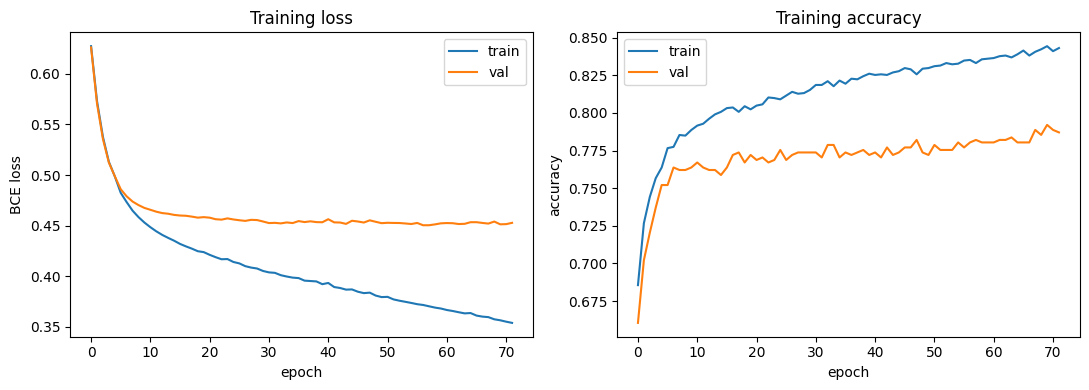

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Training accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("mlp_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluate on the test set
All metrics computed manually: accuracy, precision, recall, F1, and AUC (trapezoidal rule).

In [9]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # manual AUC: sort predictions descending, walk through and use trapezoidal rule on the ROC curve
    order = np.argsort(-y_prob)
    y_sorted = y_true[order]
    cum_tp = np.cumsum(y_sorted)
    cum_fp = np.cumsum(1 - y_sorted)
    tpr = cum_tp / cum_tp[-1] if cum_tp[-1] > 0 else cum_tp
    fpr = cum_fp / cum_fp[-1] if cum_fp[-1] > 0 else cum_fp
    # prepend (0, 0) so the curve starts at the origin
    tpr = np.concatenate([[0.0], tpr])
    fpr = np.concatenate([[0.0], fpr])
    auc = float(np.trapezoid(tpr, fpr))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion": np.array([[tn, fp], [fn, tp]]),
        "tpr": tpr,
        "fpr": fpr,
    }


y_prob_test = model.predict_proba(X_test)
metrics = compute_metrics(y_test, y_prob_test)

print("Test results")
print(f"  accuracy : {metrics['accuracy']:.4f}")
print(f"  precision: {metrics['precision']:.4f}")
print(f"  recall   : {metrics['recall']:.4f}")
print(f"  f1       : {metrics['f1']:.4f}")
print(f"  auc      : {metrics['auc']:.4f}")
print()
print("Confusion matrix:")
print("              pred 0   pred 1")
print(f"  actual 0 : {metrics['confusion'][0,0]:7d} {metrics['confusion'][0,1]:8d}")
print(f"  actual 1 : {metrics['confusion'][1,0]:7d} {metrics['confusion'][1,1]:8d}")

Test results
  accuracy : 0.8101
  precision: 0.8468
  recall   : 0.8690
  f1       : 0.8577
  auc      : 0.8624

Confusion matrix:
              pred 0   pred 1
  actual 0 :     179       78
  actual 1 :      65      431


## Confusion matrix and ROC curve

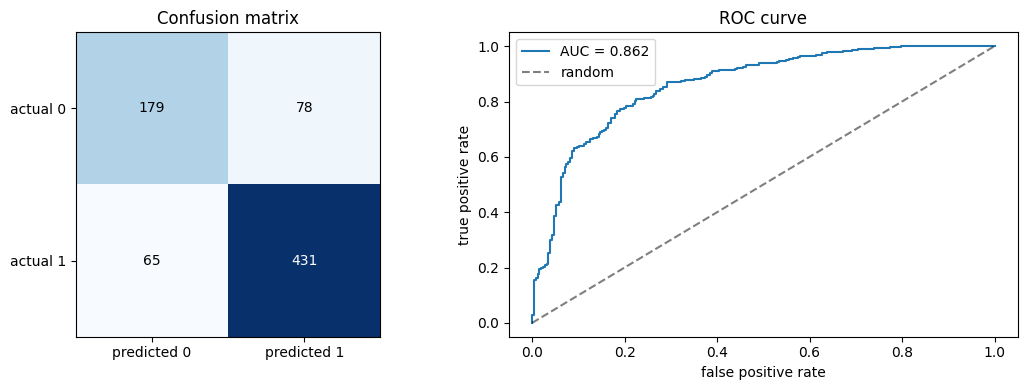

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# confusion matrix heatmap
cm = metrics["confusion"]
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["predicted 0", "predicted 1"])
axes[0].set_yticklabels(["actual 0", "actual 1"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[0].set_title("Confusion matrix")

# roc curve
axes[1].plot(metrics["fpr"], metrics["tpr"], label=f"AUC = {metrics['auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="random")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("mlp_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## Sample predictions
Top predicted hits plus some "surprises" where the model was confidently wrong.

In [11]:
# run predictions on the full dataset so we can look at titles
X_all_raw = df[feature_cols].to_numpy(dtype=float)
X_all = (X_all_raw - mean) / std

df["pred_proba"] = model.predict_proba(X_all)
df["pred_class"] = (df["pred_proba"] >= 0.5).astype(int)

print("Top predicted successes:")
print(df.sort_values("pred_proba", ascending=False)[["title", "pred_proba", "success"]].head(10).to_string(index=False))

print()
print("Biggest false positives (high prob but actually failed):")
fp_rows = df[(df["pred_proba"] > 0.8) & (df["success"] == 0)].sort_values("pred_proba", ascending=False)
print(fp_rows[["title", "pred_proba", "budget", "revenue"]].head(10).to_string(index=False))

print()
print("Biggest false negatives (unexpected hits):")
fn_rows = df[(df["pred_proba"] < 0.2) & (df["success"] == 1)].sort_values("pred_proba")
print(fn_rows[["title", "pred_proba", "budget", "revenue"]].head(10).to_string(index=False))

Top predicted successes:
                                  title  pred_proba  success
        Snow White and the Seven Dwarfs    0.999528        1
                               Fantasia    0.999337        1
                               Deadpool    0.999193        1
Harry Potter and the Chamber of Secrets    0.999161        1
                                  Bambi    0.999142        1
                    Singin' in the Rain    0.999119        1
                           Modern Times    0.999100        1
                Guardians of the Galaxy    0.999050        1
                       The Wizard of Oz    0.998981        1
                            Snowpiercer    0.998940        1

Biggest false positives (high prob but actually failed):
                       title  pred_proba    budget   revenue
               Seven Samurai    0.996618   2000000    271841
               The Interview    0.982556  44000000  12342632
   One Direction: This Is Us    0.982028  10000000         0
  

## Save metrics
Dump the key numbers so we can reference them in the report.

In [12]:
final = {
    "accuracy": float(metrics["accuracy"]),
    "precision": float(metrics["precision"]),
    "recall": float(metrics["recall"]),
    "f1": float(metrics["f1"]),
    "auc": float(metrics["auc"]),
    "confusion_matrix": metrics["confusion"].tolist(),
    "n_features": int(X.shape[1]),
    "n_train": int(len(X_tr)),
    "n_val": int(len(X_val)),
    "n_test": int(len(X_test)),
    "epochs_ran": int(len(history["train_loss"])),
}

with open("mlp_metrics.json", "w") as f:
    json.dump(final, f, indent=2)

print("saved mlp_metrics.json")
print(json.dumps(final, indent=2))

saved mlp_metrics.json
{
  "accuracy": 0.8100929614873837,
  "precision": 0.8467583497053045,
  "recall": 0.8689516129032258,
  "f1": 0.8577114427860697,
  "auc": 0.8624325342035898,
  "confusion_matrix": [
    [
      179,
      78
    ],
    [
      65,
      431
    ]
  ],
  "n_features": 37,
  "n_train": 2408,
  "n_val": 601,
  "n_test": 753,
  "epochs_ran": 72
}


## Save model artifacts for the Streamlit app

Save the trained weights and the preprocessing info so we can load them in the Streamlit app without retraining every time the app restarts.


In [13]:
# save everything the app needs: weights, normalization stats, feature order, vocab
np.savez(
    "model_artifacts.npz",
    W1=model.W1, b1=model.b1,
    W2=model.W2, b2=model.b2,
    W3=model.W3, b3=model.b3,
    feature_mean=mean,
    feature_std=std,
    feature_cols=np.array(feature_cols, dtype=object),
    all_genres=np.array(all_genres, dtype=object),
    lang_vals=np.array(lang_vals, dtype=object),
    top_langs=np.array(top_langs.tolist(), dtype=object),
)
print("saved model_artifacts.npz")

saved model_artifacts.npz
